In [ ]:
# TESTING

!pip install accelerate

In [ ]:
# TESTING

!pip install transformers torch==2.5.0

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 906.4/906.4 MB 1.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 109.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 98.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 68.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 14.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 8.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 7.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 188.7/188.7 MB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 41.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd

# Assuming the CSV file is located in the Google Drive 'Collabs' folder as specified
df = pd.read_csv('/content/drive/MyDrive/Collabs/TREMODATAcalibrationApr2024.csv')

# Print the first five rows of the dataframe to verify it's loaded correctly
print(df.head())


                                               Entry ValidatedEmotion
0            insanların düşünmeden hareket etmeleri.            anger
1  112 çıkartmalı albümüm vardı. 109. sıra geldiğ...            anger
2  hastanede bir hasta ile uğraşırken diğerlerini...            anger
3  söz verip yerine getirilmemesinde çok öfkelendim.            anger
4  aptal insanların toplumda söz sahibi olmaların...            anger


In [ ]:
import pandas as pd

# Create a dictionary to map string labels to numeric labels
kategori = {'happy':0, 'fear':1, 'sadness':2,
            'disgust':3, 'surprise':4, 'anger':5}

# Rename df to df_baru for further operations
df_baru = df.copy()

# Map the 'ValidatedEmotion' column using the dictionary to a new column 'label'
df_baru['label'] = df_baru['ValidatedEmotion'].map(kategori)

# Display the first few rows of the new DataFrame
df_baru.head()


,Entry,ValidatedEmotion,label
0,insanların düşünmeden hareket etmeleri.,anger,5
1,112 çıkartmalı albümüm vardı. 109. sıra geldiğ...,anger,5
2,hastanede bir hasta ile uğraşırken diğerlerini...,anger,5
3,söz verip yerine getirilmemesinde çok öfkelendim.,anger,5
4,aptal insanların toplumda söz sahibi olmaların...,anger,5


In [ ]:
# USE THIS CODE
import os

# Disable wandb
os.environ["WANDB_MODE"] = "disabled"

# TESTING FINALE

import numpy as np
import pandas as pd
import torch
from sklearn.model_selection import train_test_split
from transformers import BertTokenizer, BertForSequenceClassification, Trainer, TrainingArguments
from torch.utils.data import Dataset, DataLoader

class TextDataset(Dataset):
    """Custom Dataset for loading text data for PyTorch."""
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __getitem__(self, idx):
        # Ensure the tensors are contiguous before returning
        item = {key: val[idx].contiguous() for key, val in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels[idx], dtype=torch.long).contiguous()
        return item

    def __len__(self):
        return len(self.labels)

def tokenize_data(tokenizer, texts):
    """Tokenize text data using BERT tokenizer."""
    return tokenizer(texts, padding=True, truncation=True, return_tensors='pt')

def prepare_and_split_data(df, tokenizer):
    """Prepare, tokenize text and split data for model training."""
    X = df['Entry'].tolist()  # Ensure it's a list of strings
    y = df['label'].tolist()  # Convert labels to a list
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    X_train_enc = tokenize_data(tokenizer, X_train)
    X_test_enc = tokenize_data(tokenizer, X_test)
    return X_train, X_test, y_train, y_test, X_train_enc, X_test_enc

def load_model_and_tokenizer():
    """Load BERT tokenizer and sequence classification model, setting up for Turkish language."""
    tokenizer = BertTokenizer.from_pretrained('dbmdz/bert-base-turkish-cased')
    model = BertForSequenceClassification.from_pretrained('dbmdz/bert-base-turkish-cased', num_labels=6)
    return tokenizer, model

def make_model_contiguous(model):
    """Ensure all tensors in the model are contiguous."""
    for param in model.parameters():
        param.data = param.data.contiguous()

# Main execution flow starts here
kategori = {'happy': 0, 'fear': 1, 'sadness': 2, 'disgust': 3, 'surprise': 4, 'anger': 5}
df_baru['label'] = df_baru['ValidatedEmotion'].map(kategori)

tokenizer, model = load_model_and_tokenizer()

# Make sure all model parameters are contiguous
make_model_contiguous(model)

# Prepare and split data
X_train, X_test, y_train, y_test, X_train_enc, X_test_enc = prepare_and_split_data(df_baru, tokenizer)

# Create datasets for training and evaluation
train_dataset = TextDataset(X_train_enc, y_train)
test_dataset = TextDataset(X_test_enc, y_test)

# Training arguments configuration with a unique run name
training_args = TrainingArguments(
    output_dir='./results',                # output directory
    run_name="BERTurk_emotion_model_run",  # unique run name to avoid conflict
    num_train_epochs=3,                    # total number of training epochs
    per_device_train_batch_size=16,        # batch size per device during training
    per_device_eval_batch_size=64,         # batch size for evaluation
    warmup_steps=500,                      # number of warmup steps for learning rate scheduler
    weight_decay=0.01,                     # weight decay
    logging_dir='./logs',                  # directory for storing logs
    logging_steps=10,
)

# Trainer initialization and model training
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset
)

# Start training
trainer.train()

/usr/local/lib/python3.10/dist-packages/transformers/tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(
Some weights of BertForSequenceClassification were not initialized from the model checkpoint at dbmdz/bert-base-turkish-cased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Step,Training Loss
10,1.969300
20,1.924300
30,1.866800
40,1.850200
50,1.853000
60,1.758000
70,1.829500
80,1.786000
90,1.787900
100,1.791800


TrainOutput(global_step=2703, training_loss=0.3082026077852706, metrics={'train_runtime': 233.84, 'train_samples_per_second': 184.921, 'train_steps_per_second': 11.559, 'total_flos': 2600018073796104.0, 'train_loss': 0.3082026077852706, 'epoch': 3.0})

In [ ]:
# THIS CODE TO GIVE VALIDATION LOSS
# SECOND ATTEMPT
import os

# Disable wandb
os.environ["WANDB_MODE"] = "disabled"

# TESTING FINALE

import numpy as np
import pandas as pd
import torch
from sklearn.model_selection import train_test_split
from transformers import BertTokenizer, BertForSequenceClassification, Trainer, TrainingArguments
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

class TextDataset(Dataset):
    """Custom Dataset for loading text data for PyTorch."""
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __getitem__(self, idx):
        # Ensure the tensors are contiguous before returning
        item = {key: val[idx].contiguous() for key, val in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels[idx], dtype=torch.long).contiguous()
        return item

    def __len__(self):
        return len(self.labels)

def tokenize_data(tokenizer, texts):
    """Tokenize text data using BERT tokenizer."""
    return tokenizer(texts, padding=True, truncation=True, return_tensors='pt')

def prepare_and_split_data(df, tokenizer):
    """Prepare, tokenize text and split data for model training."""
    X = df['Entry'].tolist()  # Ensure it's a list of strings
    y = df['label'].tolist()  # Convert labels to a list
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    X_train_enc = tokenize_data(tokenizer, X_train)
    X_test_enc = tokenize_data(tokenizer, X_test)
    return X_train, X_test, y_train, y_test, X_train_enc, X_test_enc

def load_model_and_tokenizer():
    """Load BERT tokenizer and sequence classification model, setting up for Turkish language."""
    tokenizer = BertTokenizer.from_pretrained('dbmdz/bert-base-turkish-cased')
    model = BertForSequenceClassification.from_pretrained('dbmdz/bert-base-turkish-cased', num_labels=6)
    return tokenizer, model

def make_model_contiguous(model):
    """Ensure all tensors in the model are contiguous."""
    for param in model.parameters():
        param.data = param.data.contiguous()

def compute_metrics(eval_pred):
    """Compute evaluation metrics for validation."""
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    acc = accuracy_score(labels, predictions)
    precision, recall, f1, _ = precision_recall_fscore_support(labels, predictions, average='weighted')
    return {'accuracy': acc, 'precision': precision, 'recall': recall, 'f1': f1}

# Main execution flow starts here
kategori = {'happy': 0, 'fear': 1, 'sadness': 2, 'disgust': 3, 'surprise': 4, 'anger': 5}
df_baru['label'] = df_baru['ValidatedEmotion'].map(kategori)

tokenizer, model = load_model_and_tokenizer()

# Make sure all model parameters are contiguous
make_model_contiguous(model)

# Prepare and split data
X_train, X_test, y_train, y_test, X_train_enc, X_test_enc = prepare_and_split_data(df_baru, tokenizer)

# Create datasets for training and evaluation
train_dataset = TextDataset(X_train_enc, y_train)
test_dataset = TextDataset(X_test_enc, y_test)

# Training arguments configuration with a unique run name and evaluation strategy
training_args = TrainingArguments(
    output_dir='./results',                # output directory
    run_name="BERTurk_emotion_model_run",  # unique run name to avoid conflict
    max_steps=1200,                        # limit the number of training steps
    num_train_epochs=3,                    # total number of training epochs
    per_device_train_batch_size=16,        # batch size per device during training
    per_device_eval_batch_size=64,         # batch size for evaluation
    warmup_steps=500,                      # number of warmup steps for learning rate scheduler
    weight_decay=0.01,                     # weight decay
    logging_dir='./logs',                  # directory for storing logs
    logging_steps=10,
    evaluation_strategy="steps",           # evaluate at the end of each epoch
    save_strategy="epoch"                  # save model at the end of each epoch
)

# Trainer initialization and model training with compute_metrics
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    compute_metrics=compute_metrics
)

# Start training
trainer.train()

# After training, filter log history to extract training and validation metrics
train_loss = None
eval_loss = None
eval_metrics = None

# Look for the latest training and evaluation entries with 'loss' and 'eval_loss'
for entry in reversed(trainer.state.log_history):
    if 'loss' in entry and train_loss is None:
        train_loss = entry['loss']
    if 'eval_loss' in entry and eval_loss is None:
        eval_loss = entry['eval_loss']
        eval_metrics = {k: entry[k] for k in entry if k.startswith('eval_')}
    if train_loss is not None and eval_loss is not None:
        break

print("Training Loss:", train_loss)
print("Validation Loss:", eval_loss)
if eval_metrics:
    print("Validation Accuracy:", eval_metrics.get('eval_accuracy'))
    print("Validation Precision:", eval_metrics.get('eval_precision'))
    print("Validation Recall:", eval_metrics.get('eval_recall'))
    print("Validation F1:", eval_metrics.get('eval_f1'))

/usr/local/lib/python3.10/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/60.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/251k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/385 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/445M [00:00<?, ?B/s]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at dbmdz/bert-base-turkish-cased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/usr/local/lib/python3.10/dist-packages/transformers/training_args.py:1568: FutureWarning: `evaluation_strategy` is deprecated and will be removed in version 4.46 of 🤗 Transformers. Use `eval_strategy` instead
  warnings.warn(
max_steps is given, it will override any value given in num_train_epochs


Step,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
10,1.778000,1.838702,0.172586,0.126910,0.172586,0.061117
20,1.853800,1.831861,0.172031,0.127485,0.172031,0.060340
30,1.838400,1.819006,0.172586,0.112102,0.172586,0.062632
40,1.854000,1.804711,0.174251,0.082848,0.174251,0.067778
50,1.814600,1.794084,0.177580,0.281403,0.177580,0.072239
60,1.786100,1.785220,0.179245,0.094990,0.179245,0.074444
70,1.816300,1.771075,0.261099,0.351308,0.261099,0.203007
80,1.795100,1.759100,0.250277,0.390587,0.250277,0.185589
90,1.797800,1.747993,0.266926,0.179605,0.266926,0.168850
100,1.758500,1.721365,0.307159,0.502358,0.307159,0.232825


/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/m

Training Loss: 0.1873
Validation Loss: 0.2478373944759369
Validation Accuracy: 0.9261931187569368
Validation Precision: 0.9263135301244493
Validation Recall: 0.9261931187569368
Validation F1: 0.9261625860813201


In [ ]:
print(trainer.state.log_history[0])

{'loss': 1.778, 'grad_norm': 6.882755279541016, 'learning_rate': 1.0000000000000002e-06, 'epoch': 0.011098779134295227, 'step': 10}


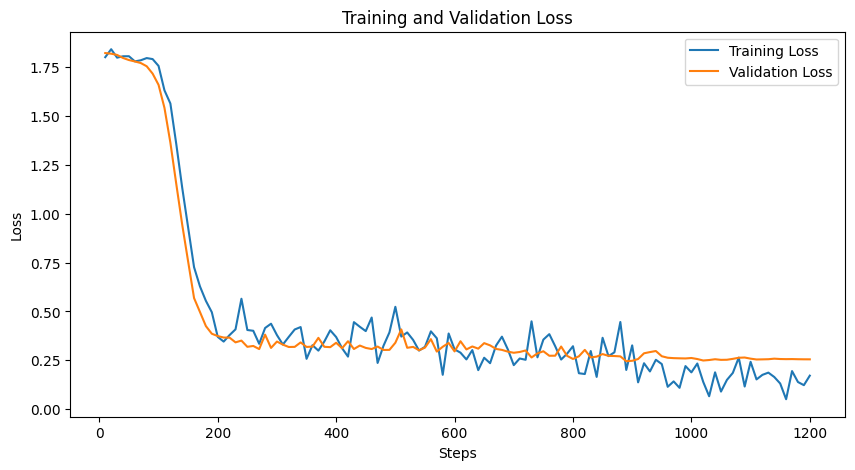

In [ ]:
import matplotlib.pyplot as plt

# Collect all training and validation loss values from log history
training_losses = []
validation_losses = []

# Iterate over log history and extract training and validation losses
for entry in trainer.state.log_history:
    if 'loss' in entry:
        training_losses.append((entry['step'], entry['loss']))
    if 'eval_loss' in entry:
        validation_losses.append((entry['step'], entry['eval_loss']))

# Separate steps and loss values for plotting
train_steps, train_loss_values = zip(*training_losses) if training_losses else ([], [])
eval_steps, eval_loss_values = zip(*validation_losses) if validation_losses else ([], [])

# Plot training and validation losses
plt.figure(figsize=(10, 5))
plt.plot(train_steps, train_loss_values, label='Training Loss')
plt.plot(eval_steps, eval_loss_values, label='Validation Loss')
plt.xlabel('Steps')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.show()

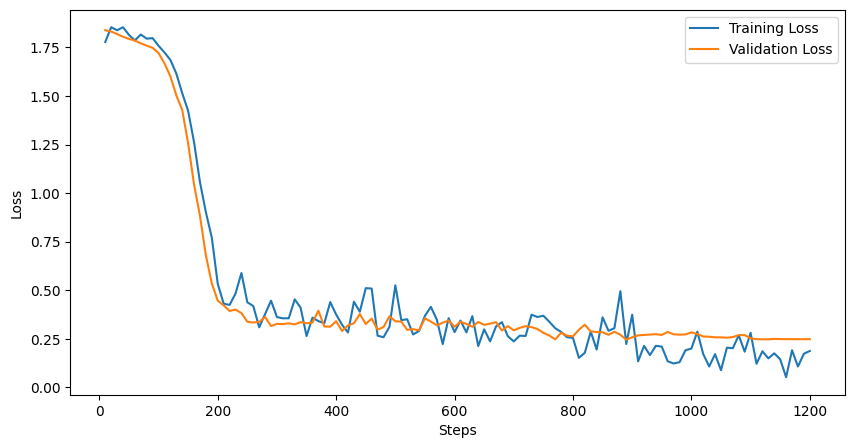

In [ ]:
# 600 DPI CHART FILE

import matplotlib.pyplot as plt

# Collect all training and validation loss values from log history
training_losses = []
validation_losses = []

# Iterate over log history and extract training and validation losses
for entry in trainer.state.log_history:
    if 'loss' in entry:
        training_losses.append((entry['step'], entry['loss']))
    if 'eval_loss' in entry:
        validation_losses.append((entry['step'], entry['eval_loss']))

# Separate steps and loss values for plotting
train_steps, train_loss_values = zip(*training_losses) if training_losses else ([], [])
eval_steps, eval_loss_values = zip(*validation_losses) if validation_losses else ([], [])

# Plot training and validation losses
plt.figure(figsize=(10, 5))
plt.plot(train_steps, train_loss_values, label='Training Loss')
plt.plot(eval_steps, eval_loss_values, label='Validation Loss')
plt.xlabel('Steps')
plt.ylabel('Loss')
# plt.title('Training and Validation Loss')
plt.legend()

# Save the plot as a TIFF file with 600 dpi
plt.savefig('Figure_4.tiff', format='tiff', dpi=600)
plt.show()

In [ ]:
# 600 DPI CHART FILE

from google.colab import files
files.download('Figure_4.tiff')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# Export training and validation losses to CSV
loss_df.to_csv('/content/drive/MyDrive/Collabs/training_validation_losses.csv', index=False)
print("Training and validation losses exported to '/content/drive/MyDrive/Collabs/training_validation_losses.csv'")

# Export evaluation metrics to CSV if they exist
if eval_metrics:
    metrics_df = pd.DataFrame([{
        'Validation Accuracy': eval_metrics.get('eval_accuracy'),
        'Validation Precision': eval_metrics.get('eval_precision'),
        'Validation Recall': eval_metrics.get('eval_recall'),
        'Validation F1': eval_metrics.get('eval_f1')
    }])

    metrics_df.to_csv('/content/drive/MyDrive/Collabs/evaluation_metrics.csv', index=False)
    print("Evaluation metrics exported to '/content/drive/MyDrive/Collabs/evaluation_metrics.csv'")

Training and validation losses exported to '/content/drive/MyDrive/Collabs/training_validation_losses.csv'
Evaluation metrics exported to '/content/drive/MyDrive/Collabs/evaluation_metrics.csv'


In [ ]:
import pandas as pd

# Create DataFrames for training and validation losses
train_df = pd.DataFrame(training_losses, columns=['Step', 'Training Loss'])
eval_df = pd.DataFrame(validation_losses, columns=['Step', 'Validation Loss'])

# Merge the DataFrames on 'Step' to align training and validation losses side by side
loss_df = pd.merge(train_df, eval_df, on='Step', how='outer').sort_values(by='Step').reset_index(drop=True)

# Export to CSV
loss_df.to_csv('training_validation_losses.csv', index=False)
print("Data exported to 'training_validation_losses.csv'")

Data exported to 'training_validation_losses.csv'


In [ ]:
# TANPA EXPORT KE CSV 'training_validation_losses.csv'

import pandas as pd

# Create DataFrames for training and validation losses
train_df = pd.DataFrame(training_losses, columns=['Step', 'Training Loss'])
eval_df = pd.DataFrame(validation_losses, columns=['Step', 'Validation Loss'])

# Merge the DataFrames on 'Step' to align training and validation losses side by side
loss_df = pd.merge(train_df, eval_df, on='Step', how='outer').sort_values(by='Step').reset_index(drop=True)

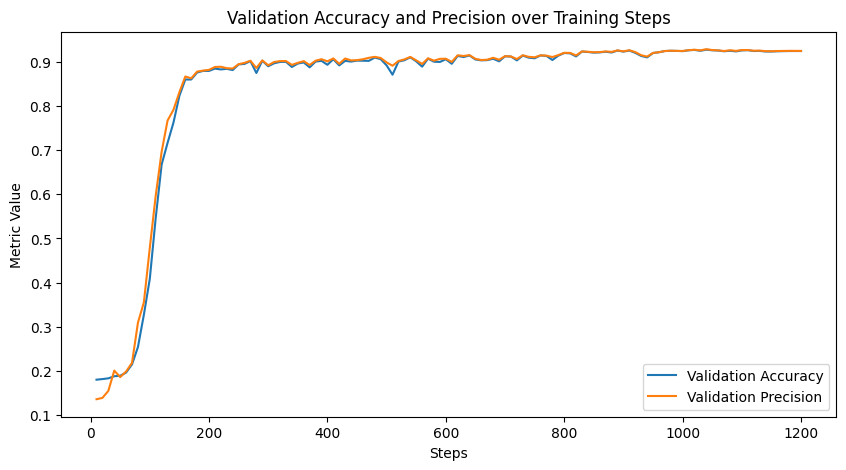

In [ ]:
import matplotlib.pyplot as plt

# Collect all accuracy and precision values from log history
accuracy_values = []
precision_values = []

# Iterate over log history and extract accuracy and precision metrics
for entry in trainer.state.log_history:
    if 'eval_accuracy' in entry:
        accuracy_values.append((entry['step'], entry['eval_accuracy']))
    if 'eval_precision' in entry:
        precision_values.append((entry['step'], entry['eval_precision']))

# Separate steps and metric values for plotting
acc_steps, acc_values = zip(*accuracy_values) if accuracy_values else ([], [])
prec_steps, prec_values = zip(*precision_values) if precision_values else ([], [])

# Plot accuracy and precision
plt.figure(figsize=(10, 5))
plt.plot(acc_steps, acc_values, label='Validation Accuracy')
plt.plot(prec_steps, prec_values, label='Validation Precision')
plt.xlabel('Steps')
plt.ylabel('Metric Value')
plt.title('Validation Accuracy and Precision over Training Steps')
plt.legend()
plt.show()

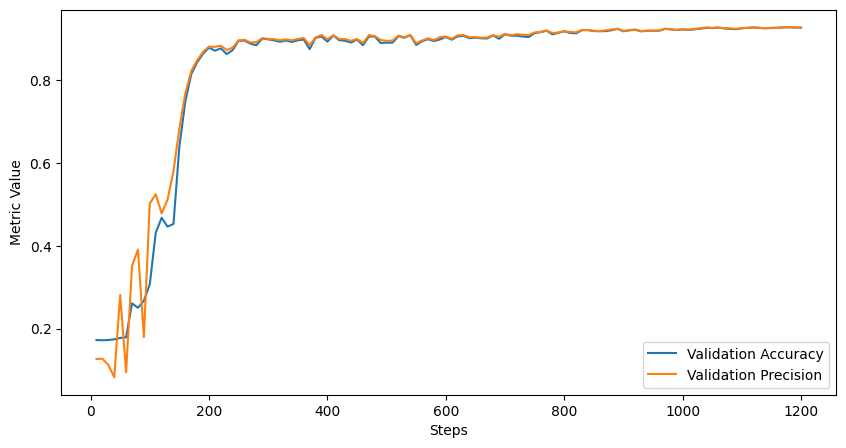

In [ ]:
# 600 DPI CHART FILE

import matplotlib.pyplot as plt

# Collect all accuracy and precision values from log history
accuracy_values = []
precision_values = []

# Iterate over log history and extract accuracy and precision metrics
for entry in trainer.state.log_history:
    if 'eval_accuracy' in entry:
        accuracy_values.append((entry['step'], entry['eval_accuracy']))
    if 'eval_precision' in entry:
        precision_values.append((entry['step'], entry['eval_precision']))

# Separate steps and metric values for plotting
acc_steps, acc_values = zip(*accuracy_values) if accuracy_values else ([], [])
prec_steps, prec_values = zip(*precision_values) if precision_values else ([], [])

# Plot accuracy and precision
plt.figure(figsize=(10, 5))
plt.plot(acc_steps, acc_values, label='Validation Accuracy')
plt.plot(prec_steps, prec_values, label='Validation Precision')
plt.xlabel('Steps')
plt.ylabel('Metric Value')
plt.legend()

# Save the plot as a TIFF file with 600 dpi
plt.savefig('Figure_5.tiff', format='tiff', dpi=600)
plt.show()

In [ ]:
# 600 DPI CHART FILE

from google.colab import files
files.download('Figure_5.tiff')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

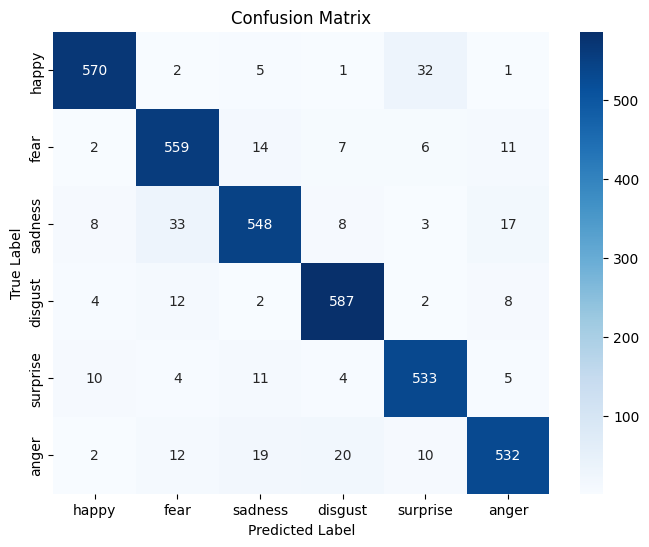

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Get predictions on the test dataset
predictions = trainer.predict(test_dataset)
pred_labels = np.argmax(predictions.predictions, axis=1)
true_labels = predictions.label_ids

# Compute confusion matrix
cm = confusion_matrix(true_labels, pred_labels)

# Define class labels (update based on your emotion classes)
class_names = ['happy', 'fear', 'sadness', 'disgust', 'surprise', 'anger']

# Plot confusion matrix as a heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

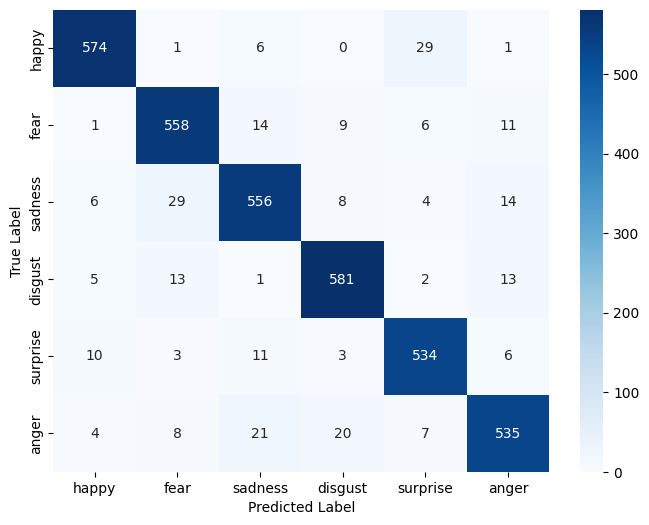

In [ ]:
# 600 DPI CHART FILE

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import numpy as np

# Get predictions on the test dataset
predictions = trainer.predict(test_dataset)
pred_labels = np.argmax(predictions.predictions, axis=1)
true_labels = predictions.label_ids

# Compute confusion matrix
cm = confusion_matrix(true_labels, pred_labels)

# Define class labels (update based on your emotion classes)
class_names = ['happy', 'fear', 'sadness', 'disgust', 'surprise', 'anger']

# Plot confusion matrix as a heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')

# Save the plot as a TIFF file with 600 dpi
plt.savefig('Figure_6.tiff', format='tiff', dpi=600)
plt.show()

In [ ]:
# 600 DPI CHART FILE

from google.colab import files
files.download('Figure_6.tiff')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
def tokenize_text(text, tokenizer):
    """Tokenize text for PyTorch using the provided tokenizer."""
    return tokenizer.encode_plus(
        text,
        add_special_tokens=True,
        max_length=128,
        padding='max_length',
        truncation=True,
        return_attention_mask=True,
        return_token_type_ids=False,
        return_tensors='pt'  # Use 'pt' for PyTorch tensors
    )


In [ ]:
import torch
from torch.utils.data import Dataset, DataLoader

class TextDataset(Dataset):
    """Custom Dataset for loading text data for PyTorch."""
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __getitem__(self, idx):
        item = {key: val[idx] for key, val in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels[idx], dtype=torch.long)
        return item

    def __len__(self):
        return len(self.labels)

def encode_texts(texts, tokenizer):
    """Encode a list of texts into format suitable for PyTorch model training."""
    return tokenizer.batch_encode_plus(
        texts,
        add_special_tokens=True,
        max_length=128,
        padding='max_length',
        truncation=True,
        return_attention_mask=True,
        return_token_type_ids=False,
        return_tensors='pt'
    )

# Encode texts
X_train_encoded = encode_texts(X_train, tokenizer)
X_test_encoded = encode_texts(X_test, tokenizer)

# Create PyTorch datasets
train_dataset = TextDataset(X_train_encoded, y_train)
test_dataset = TextDataset(X_test_encoded, y_test)

# Create DataLoader for batch processing
train_loader = DataLoader(train_dataset, shuffle=True, batch_size=32)
test_loader = DataLoader(test_dataset, batch_size=32)


In [ ]:
import torch
from torch.optim import AdamW
from torch.nn import CrossEntropyLoss
from sklearn.metrics import accuracy_score


In [ ]:
# Assuming 'model' is the instance of your PyTorch model
optimizer = AdamW(model.parameters(), lr=1e-5)
loss_fn = CrossEntropyLoss()


In [ ]:
# TESTING WITH ACCURACY, PRECISION, RECALL, AND F1

import torch
import numpy as np
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

def train_model(model, train_loader, test_loader, optimizer, loss_fn, epochs=3, model_save_path='model.pth'):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)

    for epoch in range(epochs):
        model.train()
        total_loss = 0
        all_train_predictions = []
        all_train_labels = []

        for batch in train_loader:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)

            outputs = model(input_ids, attention_mask=attention_mask, labels=labels)
            loss = outputs.loss

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            total_loss += loss.item()

            logits = outputs.logits.detach().cpu().numpy()
            label_ids = labels.to('cpu').numpy()

            predictions = np.argmax(logits, axis=1).flatten()
            labels = label_ids.flatten()

            all_train_predictions.extend(predictions)
            all_train_labels.extend(labels)

        avg_train_loss = total_loss / len(train_loader)
        train_accuracy = accuracy_score(all_train_labels, all_train_predictions)
        precision, recall, f1, _ = precision_recall_fscore_support(all_train_labels, all_train_predictions, average='weighted')

        print(f"Epoch {epoch + 1}/{epochs} - Loss: {avg_train_loss:.4f}, Training Accuracy: {train_accuracy:.4f}, Precision: {precision:.4f}, Recall: {recall:.4f}, F1 Score: {f1:.4f}")

        # Evaluation phase
        model.eval()
        total_eval_loss = 0
        all_eval_predictions = []
        all_eval_labels = []

        for batch in test_loader:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)

            with torch.no_grad():
                outputs = model(input_ids, attention_mask=attention_mask, labels=labels)

            loss = outputs.loss
            total_eval_loss += loss.item()

            logits = outputs.logits.detach().cpu().numpy()
            label_ids = labels.to('cpu').numpy()

            predictions = np.argmax(logits, axis=1).flatten()
            labels = label_ids.flatten()

            all_eval_predictions.extend(predictions)
            all_eval_labels.extend(labels)

        avg_eval_loss = total_eval_loss / len(test_loader)
        eval_accuracy = accuracy_score(all_eval_labels, all_eval_predictions)
        precision, recall, f1, _ = precision_recall_fscore_support(all_eval_labels, all_eval_predictions, average='weighted')

        print(f"Validation Accuracy: {eval_accuracy:.4f}, Precision: {precision:.4f}, Recall: {recall:.4f}, F1 Score: {f1:.4f}")

    # Save the model's state dictionary
    torch.save(model.state_dict(), model_save_path)
    print(f"Model saved to {model_save_path}")

# Example usage (only for testing the validation accuracy)
# train_model(model, train_loader, test_loader, optimizer, loss_fn, epochs=6)

# Example usage (for working research - give "#" if not used)
train_model(model, train_loader, test_loader, optimizer, loss_fn, epochs=6, model_save_path='/content/drive/My Drive/Collabs/model_tremo_v14')

Epoch 1/6 - Loss: 0.0540, Training Accuracy: 0.9824, Precision: 0.9824, Recall: 0.9824, F1 Score: 0.9824
Validation Accuracy: 0.9243, Precision: 0.9244, Recall: 0.9243, F1 Score: 0.9241
Epoch 2/6 - Loss: 0.0350, Training Accuracy: 0.9895, Precision: 0.9895, Recall: 0.9895, F1 Score: 0.9895
Validation Accuracy: 0.9270, Precision: 0.9276, Recall: 0.9270, F1 Score: 0.9271
Epoch 3/6 - Loss: 0.0290, Training Accuracy: 0.9899, Precision: 0.9899, Recall: 0.9899, F1 Score: 0.9899
Validation Accuracy: 0.9237, Precision: 0.9242, Recall: 0.9237, F1 Score: 0.9238
Epoch 4/6 - Loss: 0.0221, Training Accuracy: 0.9913, Precision: 0.9913, Recall: 0.9913, F1 Score: 0.9913
Validation Accuracy: 0.9234, Precision: 0.9239, Recall: 0.9234, F1 Score: 0.9234


KeyboardInterrupt: 

In [ ]:
# TESTING WITH ACCURACY

# Saving the state dictionary model.

import torch
import numpy as np

def train_model(model, train_loader, test_loader, optimizer, loss_fn, epochs=3, model_save_path='model.pth'):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)

    for epoch in range(epochs):
        model.train()
        total_loss = 0
        total_train_accuracy = 0
        total_train_samples = 0

        for batch in train_loader:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)

            outputs = model(input_ids, attention_mask=attention_mask, labels=labels)
            loss = outputs.loss

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            total_loss += loss.item()

            logits = outputs.logits.detach().cpu().numpy()
            label_ids = labels.to('cpu').numpy()

            predictions = np.argmax(logits, axis=1).flatten()
            labels = label_ids.flatten()
            total_train_accuracy += np.sum(predictions == labels)
            total_train_samples += labels.size

        avg_train_loss = total_loss / len(train_loader)
        avg_train_accuracy = total_train_accuracy / total_train_samples
        print(f"Epoch {epoch + 1}/{epochs} - Loss: {avg_train_loss}, Training Accuracy: {avg_train_accuracy}")

        model.eval()
        total_eval_accuracy = 0
        total_eval_loss = 0
        for batch in test_loader:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)

            with torch.no_grad():
                outputs = model(input_ids, attention_mask=attention_mask, labels=labels)

            loss = outputs.loss
            total_eval_loss += loss.item()

            logits = outputs.logits.detach().cpu().numpy()
            label_ids = labels.to('cpu').numpy()

            predictions = np.argmax(logits, axis=1).flatten()
            labels = label_ids.flatten()
            total_eval_accuracy += np.sum(predictions == labels)

        avg_val_accuracy = total_eval_accuracy / len(test_loader.dataset)
        print(f"Validation Accuracy: {avg_val_accuracy}")

    # Save the model's state dictionary
    torch.save(model.state_dict(), model_save_path)
    print(f"Model saved to {model_save_path}")

# Example usage (only for testing the validation accuracy)
#train_model(model, train_loader, test_loader, optimizer, loss_fn, epochs=6)

# Example usage (for working research - give "#" if not used)
train_model(model, train_loader, test_loader, optimizer, loss_fn, epochs=6, model_save_path='/content/drive/My Drive/Collabs/model_tremo_v14')


Epoch 1/6 - Loss: 0.05285465324239727, Training Accuracy: 0.9827945053420286
Validation Accuracy: 0.9286903440621531
Epoch 2/6 - Loss: 0.03692678005063902, Training Accuracy: 0.9877896489524074
Validation Accuracy: 0.9203662597114317
Epoch 3/6 - Loss: 0.02803489484874833, Training Accuracy: 0.9902872207575968
Validation Accuracy: 0.9223085460599334
Epoch 4/6 - Loss: 0.024053404344263344, Training Accuracy: 0.9917441376439573
Validation Accuracy: 0.9253607103218646
Epoch 5/6 - Loss: 0.023712288189866267, Training Accuracy: 0.9918828916331345
Validation Accuracy: 0.9250832408435072
Epoch 6/6 - Loss: 0.017978774948446224, Training Accuracy: 0.9933398085194949
Validation Accuracy: 0.9253607103218646
Model saved to /content/drive/My Drive/Collabs/model_tremo_v8


In [ ]:
# model_training.py

import torch
import numpy as np
import csv

def train_model(model, train_loader, test_loader, optimizer, loss_fn, epochs=3, model_save_path='model.pth', results_file='/content/drive/My Drive/Collabs/epochresultv1.csv'):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)

    # List to store epoch results
    epoch_results = []

    for epoch in range(epochs):
        model.train()
        total_loss = 0
        total_train_accuracy = 0
        total_train_samples = 0

        for batch in train_loader:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)

            outputs = model(input_ids, attention_mask=attention_mask, labels=labels)
            loss = outputs.loss

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            total_loss += loss.item()

            logits = outputs.logits.detach().cpu().numpy()
            label_ids = labels.to('cpu').numpy()

            predictions = np.argmax(logits, axis=1).flatten()
            labels = label_ids.flatten()
            total_train_accuracy += np.sum(predictions == labels)
            total_train_samples += labels.size

        avg_train_loss = total_loss / len(train_loader)
        avg_train_accuracy = total_train_accuracy / total_train_samples
        print(f"Epoch {epoch + 1}/{epochs} - Loss: {avg_train_loss}, Training Accuracy: {avg_train_accuracy}")

        model.eval()
        total_eval_accuracy = 0
        total_eval_loss = 0
        for batch in test_loader:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)

            with torch.no_grad():
                outputs = model(input_ids, attention_mask=attention_mask, labels=labels)

            loss = outputs.loss
            total_eval_loss += loss.item()

            logits = outputs.logits.detach().cpu().numpy()
            label_ids = labels.to('cpu').numpy()

            predictions = np.argmax(logits, axis=1).flatten()
            labels = label_ids.flatten()
            total_eval_accuracy += np.sum(predictions == labels)

        avg_val_accuracy = total_eval_accuracy / len(test_loader.dataset)
        print(f"Validation Accuracy: {avg_val_accuracy}")

        # Append the epoch result to the list
        epoch_results.append([epoch + 1, avg_train_loss, avg_train_accuracy, avg_val_accuracy])

    # Save the epoch results to a CSV file at the specified path
    with open(results_file, mode='w', newline='') as file:
        writer = csv.writer(file)
        writer.writerow(['Epoch', 'Train Loss', 'Train Accuracy', 'Validation Accuracy'])
        writer.writerows(epoch_results)

    # Save the model's state dictionary
    torch.save(model.state_dict(), model_save_path)
    print(f"Model saved to {model_save_path}")
    print(f"Epoch results saved to {results_file}")

# Example usage
# train_model(model, train_loader

In [ ]:
# DO NOT USE THIS CODE
# TESTING WITH ACCURACY BUT TO RESLOVE OVERFITTING LIKE ABOVE CODE

# Saving the state dictionary model.

import torch
import numpy as np
from torch import nn, optim

# Define a function to add dropout to the BERT model
def add_dropout(model, dropout_rate=0.3):
    for name, module in model.named_modules():
        if isinstance(module, nn.Linear):
            model.add_module(name, nn.Sequential(module, nn.Dropout(p=dropout_rate)))
    return model

def train_model(model, train_loader, test_loader, optimizer, loss_fn, epochs=3, model_save_path='model.pth'):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)

    best_val_accuracy = 0

    for epoch in range(epochs):
        model.train()
        total_loss = 0
        total_train_accuracy = 0
        total_train_samples = 0

        for batch in train_loader:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)

            outputs = model(input_ids, attention_mask=attention_mask, labels=labels)
            loss = outputs.loss

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            total_loss += loss.item()

            logits = outputs.logits.detach().cpu().numpy()
            label_ids = labels.to('cpu').numpy()

            predictions = np.argmax(logits, axis=1).flatten()
            labels = label_ids.flatten()
            total_train_accuracy += np.sum(predictions == labels)
            total_train_samples += labels.size

        avg_train_loss = total_loss / len(train_loader)
        avg_train_accuracy = total_train_accuracy / total_train_samples
        print(f"Epoch {epoch + 1}/{epochs} - Loss: {avg_train_loss}, Training Accuracy: {avg_train_accuracy}")

        model.eval()
        total_eval_accuracy = 0
        total_eval_loss = 0
        for batch in test_loader:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)

            with torch.no_grad():
                outputs = model(input_ids, attention_mask=attention_mask, labels=labels)

            loss = outputs.loss
            total_eval_loss += loss.item()

            logits = outputs.logits.detach().cpu().numpy()
            label_ids = labels.to('cpu').numpy()

            predictions = np.argmax(logits, axis=1).flatten()
            labels = label_ids.flatten()
            total_eval_accuracy += np.sum(predictions == labels)

        avg_val_accuracy = total_eval_accuracy / len(test_loader.dataset)
        avg_val_loss = total_eval_loss / len(test_loader)
        print(f"Validation Loss: {avg_val_loss}, Validation Accuracy: {avg_val_accuracy}")

        # Save the best model
        if avg_val_accuracy > best_val_accuracy:
            best_val_accuracy = avg_val_accuracy
            torch.save(model.state_dict(), model_save_path)
            print(f"Model saved to {model_save_path} with Validation Accuracy: {avg_val_accuracy}")

# Add dropout to the BERT model
model = add_dropout(model, dropout_rate=0.3)

# Example usage
train_model(model, train_loader, test_loader, optimizer, loss_fn, epochs=3)


KeyError: 'module name can\'t contain ".", got: model.bert.encoder.layer.0.attention.self.query'

In [ ]:
# VALIDATION ACCURACY

def evaluate_model(model, test_loader, loss_fn):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)
    model.eval()

    total_loss = 0
    correct_predictions = 0
    total_predictions = 0

    with torch.no_grad():
        for batch in test_loader:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)

            outputs = model(input_ids, attention_mask=attention_mask, labels=labels)
            loss = outputs.loss
            logits = outputs.logits

            total_loss += loss.item()

            _, predicted = torch.max(logits, dim=1)
            correct_predictions += (predicted == labels).sum().item()
            total_predictions += labels.size(0)

    avg_loss = total_loss / len(test_loader)
    accuracy = correct_predictions / total_predictions
    print(f"Test Loss: {avg_loss:.4f}, Accuracy: {accuracy:.4f}")

# Calling the evaluate function
evaluate_model(model, test_loader, loss_fn)


Test Loss: 0.3379, Accuracy: 0.9254


In [ ]:
# VERSI 1
# BISA LANGSUNG PAKE INI TANPA ATASNYA DULU, TINGGAL LOAD DATASET TWITTER
# YANG PAKE MENGGUNAKAN FILE MODEL YANG SUDAH DISIMPAN
# INI MEMAKAI THRESOLD 0.6

import torch
import pandas as pd
from torch.utils.data import Dataset, DataLoader
from transformers import BertTokenizer, BertForSequenceClassification

# Paths
MODEL_PATH = '/content/drive/My Drive/Collabs/model_tremo_v8'

# Load tokenizer and model
tokenizer = BertTokenizer.from_pretrained('dbmdz/bert-base-turkish-cased')
model = BertForSequenceClassification.from_pretrained('dbmdz/bert-base-turkish-cased', num_labels=6)
model.load_state_dict(torch.load(MODEL_PATH))
model.eval()

# Load dataset
df = pd.read_csv('/content/drive/My Drive/Collabs/silentinvasionv4_2021_2022.csv')

def encode_texts(texts, tokenizer):
    return tokenizer.batch_encode_plus(
        texts, add_special_tokens=True, max_length=128,
        padding='max_length', truncation=True, return_attention_mask=True,
        return_token_type_ids=False, return_tensors='pt'
    )

# Encode texts
texts = df['text'].tolist()
encoded_texts = encode_texts(texts, tokenizer)

class InferenceDataset(Dataset):
    def __init__(self, encodings):
        self.encodings = encodings

    def __getitem__(self, idx):
        return {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}

    def __len__(self):
        return len(self.encodings['input_ids'])

inference_dataset = InferenceDataset(encoded_texts)
inference_dataloader = DataLoader(inference_dataset, batch_size=32)

def predict_emotions(model, dataloader, threshold=0.6):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)
    predictions = []
    with torch.no_grad():
        for batch in dataloader:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            outputs = model(input_ids, attention_mask)
            logits = torch.softmax(outputs.logits, dim=1)  # Apply softmax to get probabilities
            max_probs, preds = torch.max(logits, dim=1)
            # Apply threshold to determine ambiguous
            preds[max_probs < threshold] = -1
            predictions.extend(preds.cpu().numpy())
    return predictions

emotional_analysis_results = predict_emotions(model, inference_dataloader)

# Mapping, including 'ambiguous'
emotion_categories = {-1: 'ambiguous', 0: 'happy', 1: 'fear', 2: 'sadness', 3: 'disgust', 4: 'surprise', 5: 'anger'}
df['emotion'] = [emotion_categories.get(pred, 'ambiguous') for pred in emotional_analysis_results]

# Save results
df.to_csv('/content/drive/My Drive/Collabs/silentinvasionv4_2021_2022_with_emotions_v0-6.csv', index=False)


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/60.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

config.json:   0%|          | 0.00/385 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/445M [00:00<?, ?B/s]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at dbmdz/bert-base-turkish-cased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/tmp/ipython-input-2250939277.py:39: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  return {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}


In [ ]:
# VERSI 2
# BISA LANGSUNG PAKE INI TANPA ATASNYA DULU, TINGGAL LOAD DATASET TWITTER
# YANG PAKE MENGGUNAKAN FILE MODEL YANG SUDAH DISIMPAN
# INI MEMAKAI THRESOLD 0.5

import torch
import pandas as pd
from torch.utils.data import Dataset, DataLoader
from transformers import BertTokenizer, BertForSequenceClassification

# Paths
MODEL_PATH = '/content/drive/My Drive/Collabs/model_tremo_v8'

# Load tokenizer and model
tokenizer = BertTokenizer.from_pretrained('dbmdz/bert-base-turkish-cased')
model = BertForSequenceClassification.from_pretrained('dbmdz/bert-base-turkish-cased', num_labels=6)
model.load_state_dict(torch.load(MODEL_PATH))
model.eval()

# Load dataset
df = pd.read_csv('/content/drive/My Drive/Collabs/silentinvasionv4_2021_2022.csv')

def encode_texts(texts, tokenizer):
    return tokenizer.batch_encode_plus(
        texts, add_special_tokens=True, max_length=128,
        padding='max_length', truncation=True, return_attention_mask=True,
        return_token_type_ids=False, return_tensors='pt'
    )

# Encode texts
texts = df['text'].tolist()
encoded_texts = encode_texts(texts, tokenizer)

class InferenceDataset(Dataset):
    def __init__(self, encodings):
        self.encodings = encodings

    def __getitem__(self, idx):
        return {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}

    def __len__(self):
        return len(self.encodings['input_ids'])

inference_dataset = InferenceDataset(encoded_texts)
inference_dataloader = DataLoader(inference_dataset, batch_size=32)

def predict_emotions(model, dataloader, threshold=0.5):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)
    predictions = []
    with torch.no_grad():
        for batch in dataloader:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            outputs = model(input_ids, attention_mask)
            logits = torch.softmax(outputs.logits, dim=1)  # Apply softmax to get probabilities
            max_probs, preds = torch.max(logits, dim=1)
            # Apply threshold to determine ambiguous
            preds[max_probs < threshold] = -1
            predictions.extend(preds.cpu().numpy())
    return predictions

emotional_analysis_results = predict_emotions(model, inference_dataloader)

# Mapping, including 'ambiguous'
emotion_categories = {-1: 'ambiguous', 0: 'happy', 1: 'fear', 2: 'sadness', 3: 'disgust', 4: 'surprise', 5: 'anger'}
df['emotion'] = [emotion_categories.get(pred, 'ambiguous') for pred in emotional_analysis_results]

# Save results
df.to_csv('/content/drive/My Drive/Collabs/silentinvasionv4_2021_2022_with_emotions_v0-5.csv', index=False)


/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/60.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

config.json:   0%|          | 0.00/385 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/445M [00:00<?, ?B/s]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at dbmdz/bert-base-turkish-cased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/tmp/ipython-input-922662966.py:39: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  return {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
/usr/local/lib/python3.11/dist-packages/torch/nn/modules/module.py:1750: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)


In [ ]:
# VERSI 3
# BISA LANGSUNG PAKE INI TANPA ATASNYA DULU, TINGGAL LOAD DATASET TWITTER
# YANG PAKE MENGGUNAKAN FILE MODEL YANG SUDAH DISIMPAN
# INI MEMAKAI THRESOLD 0.7

import torch
import pandas as pd
from torch.utils.data import Dataset, DataLoader
from transformers import BertTokenizer, BertForSequenceClassification

# Paths
MODEL_PATH = '/content/drive/My Drive/Collabs/model_tremo_v8'

# Load tokenizer and model
tokenizer = BertTokenizer.from_pretrained('dbmdz/bert-base-turkish-cased')
model = BertForSequenceClassification.from_pretrained('dbmdz/bert-base-turkish-cased', num_labels=6)
model.load_state_dict(torch.load(MODEL_PATH))
model.eval()

# Load dataset
df = pd.read_csv('/content/drive/My Drive/Collabs/silentinvasionv4_2021_2022.csv')

def encode_texts(texts, tokenizer):
    return tokenizer.batch_encode_plus(
        texts, add_special_tokens=True, max_length=128,
        padding='max_length', truncation=True, return_attention_mask=True,
        return_token_type_ids=False, return_tensors='pt'
    )

# Encode texts
texts = df['text'].tolist()
encoded_texts = encode_texts(texts, tokenizer)

class InferenceDataset(Dataset):
    def __init__(self, encodings):
        self.encodings = encodings

    def __getitem__(self, idx):
        return {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}

    def __len__(self):
        return len(self.encodings['input_ids'])

inference_dataset = InferenceDataset(encoded_texts)
inference_dataloader = DataLoader(inference_dataset, batch_size=32)

def predict_emotions(model, dataloader, threshold=0.7):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)
    predictions = []
    with torch.no_grad():
        for batch in dataloader:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            outputs = model(input_ids, attention_mask)
            logits = torch.softmax(outputs.logits, dim=1)  # Apply softmax to get probabilities
            max_probs, preds = torch.max(logits, dim=1)
            # Apply threshold to determine ambiguous
            preds[max_probs < threshold] = -1
            predictions.extend(preds.cpu().numpy())
    return predictions

emotional_analysis_results = predict_emotions(model, inference_dataloader)

# Mapping, including 'ambiguous'
emotion_categories = {-1: 'ambiguous', 0: 'happy', 1: 'fear', 2: 'sadness', 3: 'disgust', 4: 'surprise', 5: 'anger'}
df['emotion'] = [emotion_categories.get(pred, 'ambiguous') for pred in emotional_analysis_results]

# Save results
df.to_csv('/content/drive/My Drive/Collabs/silentinvasionv4_2021_2022_with_emotions_v0-7.csv', index=False)


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at dbmdz/bert-base-turkish-cased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/tmp/ipython-input-3131219345.py:39: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  return {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
/usr/local/lib/python3.11/dist-packages/torch/nn/modules/module.py:1750: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)


***INI BUAT DISERTASI YAA***

In [ ]:
# /content/emotion_inference_2014.py
# BISA LANGSUNG PAKE INI TANPA ATASNYA DULU, TINGGAL LOAD DATASET TWITTER
# KHUSUS DISERTASI SURIYELI 2010 - 2022
# TAHUN 2014

import torch
import pandas as pd
from torch.utils.data import Dataset, DataLoader
from transformers import BertTokenizer, BertForSequenceClassification

# Paths
MODEL_PATH = '/content/drive/My Drive/Collabs/model_tremo_v8'

# Load tokenizer and model
tokenizer = BertTokenizer.from_pretrained('dbmdz/bert-base-turkish-cased')
model = BertForSequenceClassification.from_pretrained('dbmdz/bert-base-turkish-cased', num_labels=6)
model.load_state_dict(torch.load(MODEL_PATH))
model.eval()

# Load dataset
df = pd.read_csv('/content/drive/My Drive/Collabs/alltexts_2014.csv')

# Clean text data: drop missing or non-string entries
df = df.dropna(subset=['text']).reset_index(drop=True)
df['text'] = df['text'].astype(str).str.strip()

# Encode texts
def encode_texts(texts, tokenizer):
    return tokenizer.batch_encode_plus(
        texts, add_special_tokens=True, max_length=128,
        padding='max_length', truncation=True, return_attention_mask=True,
        return_token_type_ids=False, return_tensors='pt'
    )

texts = df['text'].tolist()
encoded_texts = encode_texts(texts, tokenizer)

# Dataset for inference
class InferenceDataset(Dataset):
    def __init__(self, encodings):
        self.encodings = encodings

    def __getitem__(self, idx):
        return {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}

    def __len__(self):
        return len(self.encodings['input_ids'])

inference_dataset = InferenceDataset(encoded_texts)
inference_dataloader = DataLoader(inference_dataset, batch_size=32)

# Inference function
def predict_emotions(model, dataloader, threshold=0.6):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)
    predictions = []
    with torch.no_grad():
        for batch in dataloader:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            outputs = model(input_ids, attention_mask)
            logits = torch.softmax(outputs.logits, dim=1)  # Probabilities
            max_probs, preds = torch.max(logits, dim=1)
            preds[max_probs < threshold] = -1  # Mark ambiguous
            predictions.extend(preds.cpu().numpy())
    return predictions

# Run inference
emotional_analysis_results = predict_emotions(model, inference_dataloader)

# Map predictions to emotion labels
emotion_categories = {
    -1: 'ambiguous',
     0: 'happy',
     1: 'fear',
     2: 'sadness',
     3: 'disgust',
     4: 'surprise',
     5: 'anger'
}
df['emotion'] = [emotion_categories.get(pred, 'ambiguous') for pred in emotional_analysis_results]

# Save results
df.to_csv('/content/drive/My Drive/Collabs/alltexts_2014_with_emotions_v1.csv', index=False)

In [ ]:
# /content/emotion_inference_2016.py
# BISA LANGSUNG PAKE INI TANPA ATASNYA DULU, TINGGAL LOAD DATASET TWITTER
# KHUSUS DISERTASI SURIYELI 2010 - 2022
# TAHUN 2016

import torch
import pandas as pd
from torch.utils.data import Dataset, DataLoader
from transformers import BertTokenizer, BertForSequenceClassification

# Paths
MODEL_PATH = '/content/drive/My Drive/Collabs/model_tremo_v8'

# Load tokenizer and model
tokenizer = BertTokenizer.from_pretrained('dbmdz/bert-base-turkish-cased')
model = BertForSequenceClassification.from_pretrained('dbmdz/bert-base-turkish-cased', num_labels=6)
model.load_state_dict(torch.load(MODEL_PATH))
model.eval()

# Load dataset
df = pd.read_csv('/content/drive/My Drive/Collabs/alltexts_2016.csv')

# Clean text data: drop missing or non-string entries
df = df.dropna(subset=['text']).reset_index(drop=True)
df['text'] = df['text'].astype(str).str.strip()

# Encode texts
def encode_texts(texts, tokenizer):
    return tokenizer.batch_encode_plus(
        texts, add_special_tokens=True, max_length=128,
        padding='max_length', truncation=True, return_attention_mask=True,
        return_token_type_ids=False, return_tensors='pt'
    )

texts = df['text'].tolist()
encoded_texts = encode_texts(texts, tokenizer)

# Dataset for inference
class InferenceDataset(Dataset):
    def __init__(self, encodings):
        self.encodings = encodings

    def __getitem__(self, idx):
        return {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}

    def __len__(self):
        return len(self.encodings['input_ids'])

inference_dataset = InferenceDataset(encoded_texts)
inference_dataloader = DataLoader(inference_dataset, batch_size=32)

# Inference function
def predict_emotions(model, dataloader, threshold=0.6):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)
    predictions = []
    with torch.no_grad():
        for batch in dataloader:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            outputs = model(input_ids, attention_mask)
            logits = torch.softmax(outputs.logits, dim=1)  # Probabilities
            max_probs, preds = torch.max(logits, dim=1)
            preds[max_probs < threshold] = -1  # Mark ambiguous
            predictions.extend(preds.cpu().numpy())
    return predictions

# Run inference
emotional_analysis_results = predict_emotions(model, inference_dataloader)

# Map predictions to emotion labels
emotion_categories = {
    -1: 'ambiguous',
     0: 'happy',
     1: 'fear',
     2: 'sadness',
     3: 'disgust',
     4: 'surprise',
     5: 'anger'
}
df['emotion'] = [emotion_categories.get(pred, 'ambiguous') for pred in emotional_analysis_results]

# Save results
df.to_csv('/content/drive/My Drive/Collabs/alltexts_2016_with_emotions_v1.csv', index=False)

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at dbmdz/bert-base-turkish-cased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
<ipython-input-5-bde5a2487f46>:44: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  return {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}


In [ ]:
# /content/emotion_inference_2017.py
# BISA LANGSUNG PAKE INI TANPA ATASNYA DULU, TINGGAL LOAD DATASET TWITTER
# KHUSUS DISERTASI SURIYELI 2010 - 2022
# TAHUN 2017

import torch
import pandas as pd
from torch.utils.data import Dataset, DataLoader
from transformers import BertTokenizer, BertForSequenceClassification

# Paths
MODEL_PATH = '/content/drive/My Drive/Collabs/model_tremo_v8'

# Load tokenizer and model
tokenizer = BertTokenizer.from_pretrained('dbmdz/bert-base-turkish-cased')
model = BertForSequenceClassification.from_pretrained('dbmdz/bert-base-turkish-cased', num_labels=6)
model.load_state_dict(torch.load(MODEL_PATH))
model.eval()

# Load dataset
df = pd.read_csv('/content/drive/My Drive/Collabs/alltexts_2017.csv')

# Clean text data: drop missing or non-string entries
df = df.dropna(subset=['text']).reset_index(drop=True)
df['text'] = df['text'].astype(str).str.strip()

# Encode texts
def encode_texts(texts, tokenizer):
    return tokenizer.batch_encode_plus(
        texts, add_special_tokens=True, max_length=128,
        padding='max_length', truncation=True, return_attention_mask=True,
        return_token_type_ids=False, return_tensors='pt'
    )

texts = df['text'].tolist()
encoded_texts = encode_texts(texts, tokenizer)

# Dataset for inference
class InferenceDataset(Dataset):
    def __init__(self, encodings):
        self.encodings = encodings

    def __getitem__(self, idx):
        return {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}

    def __len__(self):
        return len(self.encodings['input_ids'])

inference_dataset = InferenceDataset(encoded_texts)
inference_dataloader = DataLoader(inference_dataset, batch_size=32)

# Inference function
def predict_emotions(model, dataloader, threshold=0.6):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)
    predictions = []
    with torch.no_grad():
        for batch in dataloader:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            outputs = model(input_ids, attention_mask)
            logits = torch.softmax(outputs.logits, dim=1)  # Probabilities
            max_probs, preds = torch.max(logits, dim=1)
            preds[max_probs < threshold] = -1  # Mark ambiguous
            predictions.extend(preds.cpu().numpy())
    return predictions

# Run inference
emotional_analysis_results = predict_emotions(model, inference_dataloader)

# Map predictions to emotion labels
emotion_categories = {
    -1: 'ambiguous',
     0: 'happy',
     1: 'fear',
     2: 'sadness',
     3: 'disgust',
     4: 'surprise',
     5: 'anger'
}
df['emotion'] = [emotion_categories.get(pred, 'ambiguous') for pred in emotional_analysis_results]

# Save results
df.to_csv('/content/drive/My Drive/Collabs/alltexts_2017_with_emotions_v1.csv', index=False)

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at dbmdz/bert-base-turkish-cased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
<ipython-input-6-eafed1f83b1e>:44: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  return {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}


In [ ]:
# /content/emotion_inference_2022.py
# BISA LANGSUNG PAKE INI TANPA ATASNYA DULU, TINGGAL LOAD DATASET TWITTER
# KHUSUS DISERTASI SURIYELI 2010 - 2022
# TAHUN 2022

import torch
import pandas as pd
from torch.utils.data import Dataset, DataLoader
from transformers import BertTokenizer, BertForSequenceClassification

# Paths
MODEL_PATH = '/content/drive/My Drive/Collabs/model_tremo_v8'

# Load tokenizer and model
tokenizer = BertTokenizer.from_pretrained('dbmdz/bert-base-turkish-cased')
model = BertForSequenceClassification.from_pretrained('dbmdz/bert-base-turkish-cased', num_labels=6)
model.load_state_dict(torch.load(MODEL_PATH))
model.eval()

# Load dataset
df = pd.read_csv('/content/drive/My Drive/Collabs/alltexts_2022.csv')

# Clean text data: drop missing or non-string entries
df = df.dropna(subset=['text']).reset_index(drop=True)
df['text'] = df['text'].astype(str).str.strip()

# Encode texts
def encode_texts(texts, tokenizer):
    return tokenizer.batch_encode_plus(
        texts, add_special_tokens=True, max_length=128,
        padding='max_length', truncation=True, return_attention_mask=True,
        return_token_type_ids=False, return_tensors='pt'
    )

texts = df['text'].tolist()
encoded_texts = encode_texts(texts, tokenizer)

# Dataset for inference
class InferenceDataset(Dataset):
    def __init__(self, encodings):
        self.encodings = encodings

    def __getitem__(self, idx):
        return {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}

    def __len__(self):
        return len(self.encodings['input_ids'])

inference_dataset = InferenceDataset(encoded_texts)
inference_dataloader = DataLoader(inference_dataset, batch_size=32)

# Inference function
def predict_emotions(model, dataloader, threshold=0.6):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)
    predictions = []
    with torch.no_grad():
        for batch in dataloader:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            outputs = model(input_ids, attention_mask)
            logits = torch.softmax(outputs.logits, dim=1)  # Probabilities
            max_probs, preds = torch.max(logits, dim=1)
            preds[max_probs < threshold] = -1  # Mark ambiguous
            predictions.extend(preds.cpu().numpy())
    return predictions

# Run inference
emotional_analysis_results = predict_emotions(model, inference_dataloader)

# Map predictions to emotion labels
emotion_categories = {
    -1: 'ambiguous',
     0: 'happy',
     1: 'fear',
     2: 'sadness',
     3: 'disgust',
     4: 'surprise',
     5: 'anger'
}
df['emotion'] = [emotion_categories.get(pred, 'ambiguous') for pred in emotional_analysis_results]

# Save results
df.to_csv('/content/drive/My Drive/Collabs/alltexts_2022_with_emotions_v1.csv', index=False)

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at dbmdz/bert-base-turkish-cased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
<ipython-input-7-2d60aa6389c4>:44: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  return {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
